### Imports

In [1]:
# Imports
import torch
from typing import List, Tuple
from dataclasses import dataclass
import signatory

import numpy as np
import torch
import pickle
import os
from pathlib import Path
import bz2
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
from minisom import MiniSom
from collections import Counter
from datetime import datetime
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,accuracy_score,jaccard_score
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Lasso
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM

### Stocks


In [2]:
folder_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files"
folder_files = os.listdir(folder_path)
parquet_files = [f for f in folder_files if f.endswith('.parquet')]
stock_dict = {}
for file in parquet_files:
    file_path = os.path.join(folder_path, file)
    df_name = os.path.splitext(file)[0] 
    stock_dict[df_name] = pd.read_parquet(file_path)  
for df_name, df in stock_dict.items():
    print(f"DataFrame for {df_name}:")
    print(df.head())  

DataFrame for AAPL_full_1min_adjsplit:
              datetime    open    high     low   close  volume
0  2005-01-03 08:00:00  1.1607  1.1613  1.1607  1.1613   39200
1  2005-01-03 08:02:00  1.1518  1.1518  1.1518  1.1518  304360
2  2005-01-03 08:03:00  1.1625  1.1627  1.1625  1.1627   16800
3  2005-01-03 08:04:00  1.1634  1.1661  1.1634  1.1661  161504
4  2005-01-03 08:07:00  1.1645  1.1645  1.1643  1.1643   50400
DataFrame for GE_full_1min_adjsplitdiv:
              datetime      open      high       low     close  volume
0  2005-01-03 08:01:00  115.5667  115.5667  115.5667  115.5667   318.0
1  2005-01-03 08:02:00  115.5667  115.5667  115.5667  115.5667   127.0
2  2005-01-03 08:04:00  115.7242  115.7242  115.7242  115.7242    31.8
3  2005-01-03 08:05:00  115.7242  115.7242  115.6612  115.6612   413.0
4  2005-01-03 08:10:00  115.7242  115.7242  115.7242  115.7242    63.5
DataFrame for JPM_full_1min_adjsplitdiv:
              datetime     open     high      low    close     volume
0  200

In [3]:
file_path1 = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files\AAPL_full_1min_adjsplit.parquet"

raw_data1 = pd.read_parquet(file_path)

In [6]:
file_path1 = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files\AAPL_full_1min_adjsplit.parquet"

raw_data1 = pd.read_parquet(file_path1)

raw_data1['datetime'] = pd.to_datetime(raw_data1['datetime'])
raw_data1['datetime'] = raw_data1['datetime']

def resample_data(data, resample_rule='5T', start_date=None, end_offset_years=2, price_column='close', volume_column='volume'):
    # Convert the 'datetime' column to datetime format
    data['datetime'] = pd.to_datetime(data['datetime'])
    
    # Set 'datetime' as the index
    data.set_index('datetime', inplace=True)
    
    # Define the end date as the given offset from the start date
    end_date = pd.to_datetime(start_date) + pd.DateOffset(years=end_offset_years)
    
    # Filter data for the defined period starting from start_date
    data = data.loc[start_date:end_date]
    
    # Resample and aggregate
    resampled_data = data.resample(resample_rule).agg({
        price_column: 'last',   # Last price in the resample window
        volume_column: 'sum',   # Sum of volume in the resample window
    })
    
    # Handle missing data by forward filling
    resampled_data.ffill(inplace=True)
    
    return resampled_data

# Perform resampling on the loaded data
start_date = '2022-01-01'  # Define start date

# Resample the data
resampled_data1 = resample_data(raw_data1, resample_rule='5T', start_date=start_date, price_column='close', volume_column='volume')

resampled_data1 = resampled_data1[:185018*100]

# Check Shapes
print(resampled_data1.shape)


# Normalize and window

data_5min_1 = resampled_data1.values 
data_5min_1 = torch.tensor(data_5min_1, dtype=torch.float32) 
data_5min_1 = st.rolling_window1(data_5min_1, window=96*10)
data_5min_1 = data_5min_1 - data_5min_1[:,0:1]
data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)

# Concatenate
multivariate_path=torch.cat([data_5min_1[:]], dim=2)
multivariate_path.shape

# Scale the mulitvaraite path
data_min = multivariate_path.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]  # Global minimum per feature
data_max = multivariate_path.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]  # Global maximum per feature

# Apply Min-Max scaling: (data - min) / (max - min)
scaled_data = (multivariate_path - data_min) / (data_max - data_min)
scaled_data = scaled_data[:192,:,:]
# Check the range of the scaled data to confirm it's between 0 and 1
scaled_data_min = scaled_data.min().item()
scaled_data_max = scaled_data.max().item()

scaled_data_min, scaled_data_max

print(scaled_data.shape)

(208990, 2)
torch.Size([192, 960, 2])


In [7]:
import torch
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Function to calculate the number of terms at a given depth using the Lie bracket formula
def num_terms_at_depth(d, n):
    """
    Compute the number of terms in the log signature at depth n using the given formula.
    
    Args:
    - d: Dimension of the input path.
    - n: Depth level.

    Returns:
    - Number of log signature terms at depth n.
    """
    result = 0
    for m in divisors(n):
        result += mobius(m) * d**(n // m)
    return result // n

# Function to rescale signature terms by the factorial of the depth level
def rescale_signature_by_factorial(signature, dimension, depth):
    """
    Multiplies the terms in the signature by the factorial of their respective depth level.
    Args:
    - signature: The signature tensor.
    - dimension: The number of input dimensions.
    - depth: The maximum depth of the signature.

    Returns:
    - Rescaled signature (factorial-weighted by depth level).
    """
    rescaled_signature = []
    current_index = 0

    for d in range(1, depth + 1):
        # Calculate the number of terms at this depth level
        n_terms_at_depth_d = num_terms_at_depth(dimension, d)
        # print(n_terms_at_depth_d)
        # print(dimension,d)
        # Compute factorial of the current depth level
        depth_factorial = math.factorial(d)

        # Extract the terms for the current depth and multiply by the depth factorial
        terms_at_depth_d = signature[..., current_index:current_index + n_terms_at_depth_d] * depth_factorial

        # Append the rescaled terms to the rescaled_signature list
        rescaled_signature.append(terms_at_depth_d)

        # Update the index to point to the next depth section
        current_index += n_terms_at_depth_d

    # Concatenate rescaled terms along the feature dimension
    return torch.cat(rescaled_signature, dim=-1)

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        # print("aug",np.isnan(aug).any())
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)
            # print("signature",np.isnan(sig).any())
            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[2]  # Number of input dimensions (e.g., 6)
            rescaled_sig = rescale_signature_by_factorial(sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(scaled_data[:], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 30])


# Save Signatures for Autoencoding

In [8]:
torch.save(results1["lead_lag_transform_log_singature"], "apple_siganture")
print(results1["lead_lag_transform_log_singature"].shape)

torch.Size([192, 30])


### VIF

In [9]:
# Function to calculate VIF
def calculate_vif(x):
    vif = [variance_inflation_factor(x.cpu().numpy(), i) for i in range(x.shape[1])]
    return torch.tensor(vif)

# Function to remove features with high VIF
def remove_vif(x, threshold=10):
    while True and x.shape[1] > 1:
        vif = calculate_vif(x)
        max_vif = torch.max(vif)  # check if largest value below threshold
        if max_vif <= threshold:
            break
        feature_to_remove = torch.argmax(vif)  # get index
        x = torch.cat((x[:, :feature_to_remove], x[:, feature_to_remove + 1:]), dim=1)  # remove highest vif
    return x

vif_cleaned_result = remove_vif(results1["lead_lag_transform_log_singature"], threshold=10)
vif_cleaned_result.shape

torch.Size([192, 11])

### Fit

In [14]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

scaler = PowerTransformer(method='yeo-johnson',standardize=True)
data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])


scaler = MinMaxScaler(feature_range=(-1, 1))
train_matrix = scaler.fit_transform(data_scaled)


train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)


# # Hirarcical som for 4 clusters tmax 5 tmin .3 , itaration 300, lr .3
params = SOMParams(map_size=(2, 1),Tmax=6,Tmin=.1,batch_size = 512,iterations = 1000, input_dims=train_matrix1.shape[1], lr=0.01, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))
gsomm = GSOMM(logger=logger, params=params)
gsomm.somm.initialize(train_matrix1)
t0 = datetime.now()

inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

2025-02-17 20:34:47,887     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 20:34:47,889     adapted_som INFO     MainThread   MainProcess Save interval: 50
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ..\aten\src\ATen\native\BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
2025-02-17 20:34:48,005     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-17 20:34:48,007     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.661, L_km = 10.63700008392334
2025-02-17 20:34:48,008     adapted_

updated
tensor(10.6366)


2025-02-17 20:34:53,632     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 20:34:53,633     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.164, L_km = 10.717000007629395
2025-02-17 20:34:53,633     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.164, som_loss = 21.163999557495117


tensor(10.7167)


2025-02-17 20:34:53,908     adapted_som INFO     MainThread   MainProcess Iteration 149 - T=N/A
2025-02-17 20:34:53,908     adapted_som INFO     MainThread   MainProcess   [Train] - L = 20.809, L_km = 10.772000312805176
2025-02-17 20:34:53,908     adapted_som INFO     MainThread   MainProcess   [Train] - L = 20.809, som_loss = 20.80900001525879


...

tensor(10.1502)


2025-02-17 20:34:58,854     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 20:34:58,854     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.15, L_km = 10.149999618530273
2025-02-17 20:34:58,854     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.15, som_loss = 10.149999618530273


tensor(10.1502)


2025-02-17 20:34:59,286     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 20:34:59,286     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.15, L_km = 10.149999618530273
2025-02-17 20:34:59,286     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.15, som_loss = 10.149999618530273


tensor(10.1502)


In [15]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

# Initializing variables to store the best model and the lowest quantization error
best_gsomm = None
lowest_quantization_error = float('inf')

# Perform the process 20 times
for i in range(20):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

    # Set SOM parameters
    params = SOMParams(map_size=(2, 1), Tmax=6, Tmin=.1, batch_size=512, iterations=1000,
                       input_dims=train_matrix1.shape[1], lr=0.01,
                       dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results")

    gsomm = GSOMM(logger=logger, params=params)
    gsomm.somm.initialize(train_matrix1)

    # Train the SOM and calculate quantization error
    inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

    # Compare the quantization error to find the best model
    if initial_quantization_error < lowest_quantization_error:
        lowest_quantization_error = initial_quantization_error
        best_gsomm = gsomm
        print(f"New best model found with quantization error: {initial_quantization_error.item()}")

# Output the lowest quantization error and the best model
print(f"Lowest quantization error: {lowest_quantization_error.item()}")


2025-02-17 20:35:06,423     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 20:35:06,425     adapted_som INFO     MainThread   MainProcess Save interval: 50
2025-02-17 20:35:06,523     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-17 20:35:06,525     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.592, L_km = 10.722999572753906
2025-02-17 20:35:06,527     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.592, som_loss = 21.591999053955078


Run 1/20
updated
tensor(10.7231)


2025-02-17 20:35:06,870     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 20:35:06,880     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.143, L_km = 10.756999969482422
2025-02-17 20:35:06,882     adapted_som INFO     MainThread   MainProcess   [Train] - L = 21.143, som_loss = 21.14299964904785


tensor(10.7566)


2025-02-17 20:35:07,172     adapted_som INFO     MainThread   MainProcess Iteration 149 - T=N/A
2025-02-17 20:35:07,178     adapted_som INFO     MainThread   MainProcess   [Train] - L = 20.802, L_km = 10.803000450134277
2025-02-17 20:35:07,178     adapted_som INFO     MainThread   MainProcess   [Train] - L = 20.802, som_loss = 20.802000045776367


...

tensor(10.1431)


2025-02-17 20:37:29,144     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 20:37:29,144     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.143, L_km = 10.142999649047852
2025-02-17 20:37:29,144     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.143, som_loss = 10.142999649047852


tensor(10.1431)


2025-02-17 20:37:29,497     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 20:37:29,501     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.143, L_km = 10.142999649047852
2025-02-17 20:37:29,502     adapted_som INFO     MainThread   MainProcess   [Train] - L = 10.143, som_loss = 10.142999649047852


tensor(10.1431)
Lowest quantization error: 1006.7194213867188


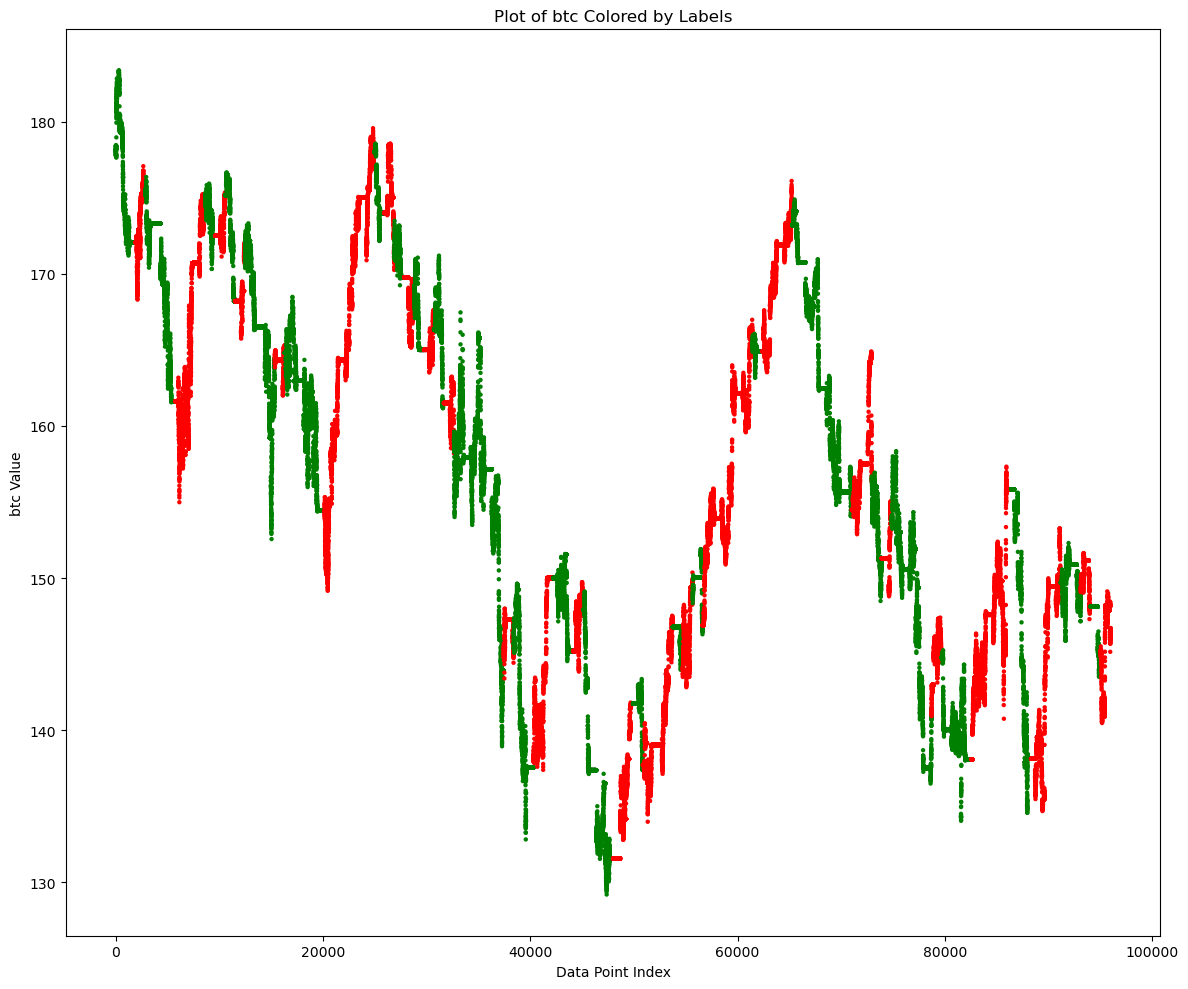

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

a,qe,_ = best_gsomm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)

# # Assuming initial_preds_rep is already defined and repeated correctly
# initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)

resampled_data1
# Assuming eth and btc data are already extracted
btc = resampled_data1.values[:96000, 0]


# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['red', 'green'])

# Create figure with two subplots
fig, axs = plt.subplots(1, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs.scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs.set_title('Plot of btc Colored by Labels')
axs.set_xlabel('Data Point Index')
axs.set_ylabel('btc Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


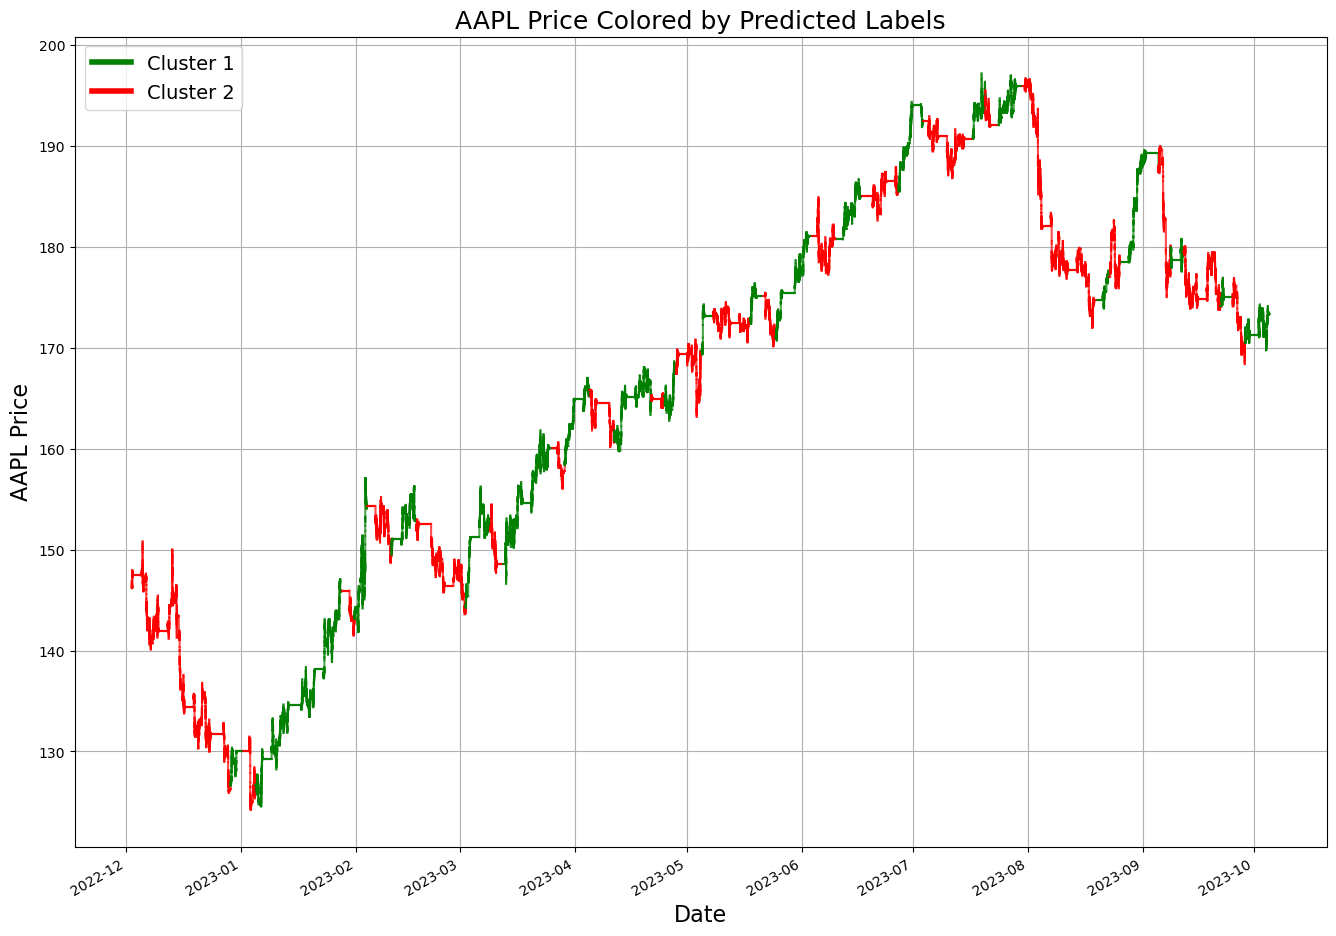

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Assuming `vif_cleaned_result` and the scalers are defined elsewhere in the code
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape

# Assuming eth, btc, and ada data are already extracted
btc = resampled_data1.values[96000:, 0]

# Get the actual date-times from `resampled_data1`
btc_dates = resampled_data1[960*100:960*192].index  # Extract the corresponding date-times for the BTC price

# Define the custom colormap: green for one label, red for the other
custom_cmap = ListedColormap(['green', 'red'])

# Create subplots
fig, axs = plt.subplots(1, 1, figsize=(14, 10))  # Increased figure size

# Plot BTC prices in segments according to cluster labels
for i in range(len(btc[:88320]) - 1):
    axs.plot([btc_dates[i], btc_dates[i+1]], [btc[i], btc[i+1]], 
             color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set the title and labels
axs.set_title('AAPL Price Colored by Predicted Labels', fontsize=18)
axs.set_xlabel('Date', fontsize=16)
axs.set_ylabel('AAPL Price', fontsize=16)
axs.grid(True)  # Add grid

# Format the x-axis to show dates nicely
fig.autofmt_xdate()

# Create a custom legend
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Cluster 1'),
                   Line2D([0], [0], color='red', lw=4, label='Cluster 2')]

# Add the legend to the plot
axs.legend(handles=legend_elements, loc='upper left', fontsize=14)


# Improve layout and add padding
plt.tight_layout(pad=3.0)

# Save the figure
plt.savefig("bitcoin_with_dates_and_labels.png")

# Show the plot
plt.show()
